# Supervised Learning

## *Workshop 9*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W09.%20Supervised%20Learning.ipynb)

This week we move from *explaining* outcomes (regression, causal inference) to *predicting* them. A supervised learning model learns the relationship between **features** (inputs) and a **label** (the outcome) from examples where we know the answer (**training**), and then makes predictions for new cases where we don't (**inference**).

We'll follow the lecture: first the Titanic, then a real monitoring problem from Global Fishing Watch, where the question is whether we can tell what kind of fishing gear a vessel uses from its size and behaviour.

### Aims

- Split data into training and test sets, and understand *why* before fitting anything
- Fit and read a **decision tree**, then a **random forest**
- Assess a classifier with a **confusion matrix**, **accuracy**, **precision**, **recall** and **F1**, and see why accuracy misleads when classes are imbalanced
- Diagnose **overfitting** (train vs test accuracy as a tree grows) and use **cross-validation**
- Interpret **feature importance**, with its caveats
- Spot **leakage**: when the answer sneaks into the features, or the same case appears in both train and test
- Think critically about **label quality**: where do the "true" labels come from?

The core path is Parts 1 to 3. Sections marked *Optional* are extensions if you finish early.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")

# Part 1: Predicting survival on the Titanic

The [Titanic dataset](https://www.kaggle.com/c/titanic/data) lists 891 passengers, whether they survived, and some facts about them:

| column | meaning |
|---|---|
| `Survived` | 1 = survived, 0 = died (**the label**) |
| `Pclass` | ticket class: 1st, 2nd, 3rd |
| `Sex`, `Age` | sex and age in years |
| `SibSp`, `Parch` | number of siblings/spouses, parents/children aboard |
| `Fare` | ticket price |
| `Embarked` | port: C = Cherbourg, Q = Queenstown, S = Southampton |

This is a **classification** problem: the label is a category (survived or not), not a continuous number.

In [2]:
df = pd.read_csv("https://storage.googleapis.com/qm2/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1.1 Descriptive statistics

Before modelling, look. Which groups survived? A model can only learn patterns that are in the data.

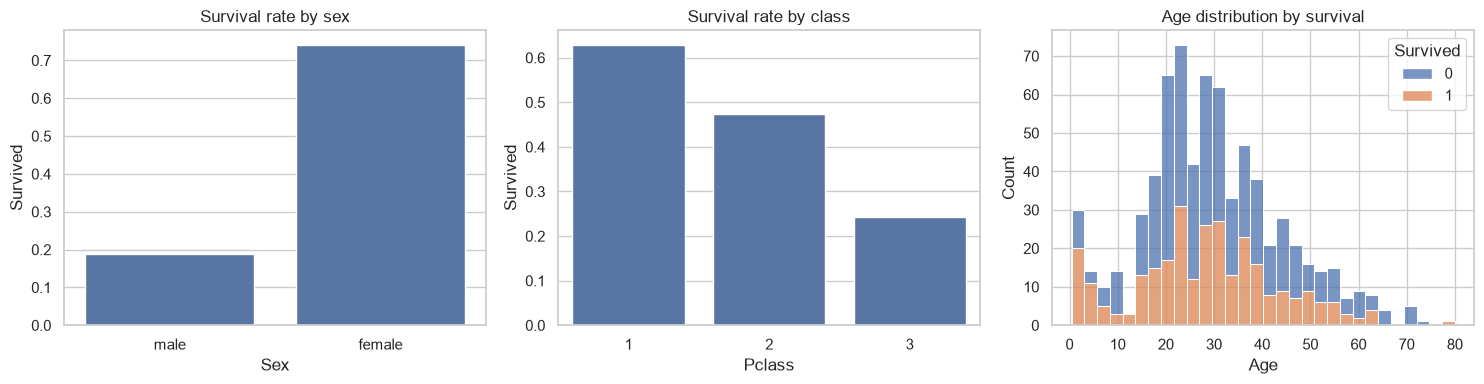

Overall survival rate: 38.4%


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=df, x="Sex", y="Survived", ax=axes[0], errorbar=None)
axes[0].set_title("Survival rate by sex")
sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1], errorbar=None)
axes[1].set_title("Survival rate by class")
sns.histplot(data=df, x="Age", hue="Survived", bins=30, multiple="stack", ax=axes[2])
axes[2].set_title("Age distribution by survival")
plt.tight_layout()
plt.show()

print(f"Overall survival rate: {df['Survived'].mean():.1%}")

Keep that last number in mind: **61.6% of passengers died**. A "model" that predicts *everyone died* is already right 61.6% of the time. Any real model has to beat this **baseline**.

## 1.2 Preparing features, then splitting *first*

scikit-learn needs numbers, so we encode `Sex` and `Embarked` as integers. `Age` is missing for 177 passengers, so we fill the gaps with the median age.

**Why split before doing anything else?** A model scored on the data it was trained on will look better than it is: it can memorise. So we lock away 20% of passengers as a **test set** that the model never sees during training. Even the median age used for filling gaps is computed from the training set only, so no information from the test set leaks in.

In [4]:
df["Sex_int"] = np.where(df["Sex"] == "male", 0, 1)
df["Embarked_int"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2}).fillna(0)

train, test = train_test_split(df, test_size=0.2, random_state=42)
train, test = train.copy(), test.copy()

median_age = train["Age"].median()          # learned from the training set only
train["Age"] = train["Age"].fillna(median_age)
test["Age"] = test["Age"].fillna(median_age)

y_train, y_test = train["Survived"], test["Survived"]
print(len(train), "training passengers;", len(test), "test passengers")

712 training passengers; 179 test passengers


`random_state=42` fixes the random shuffle, so everyone gets the same split and the same numbers. Change it and your results will move a little: that's worth remembering whenever someone reports a single accuracy figure to one decimal place.

## 1.3 The decision tree

A decision tree asks a sequence of yes/no questions about the features, choosing at each step the question that best separates survivors from non-survivors. Let's grow a small one (maximum depth 3) using sex, age and class, and draw it.

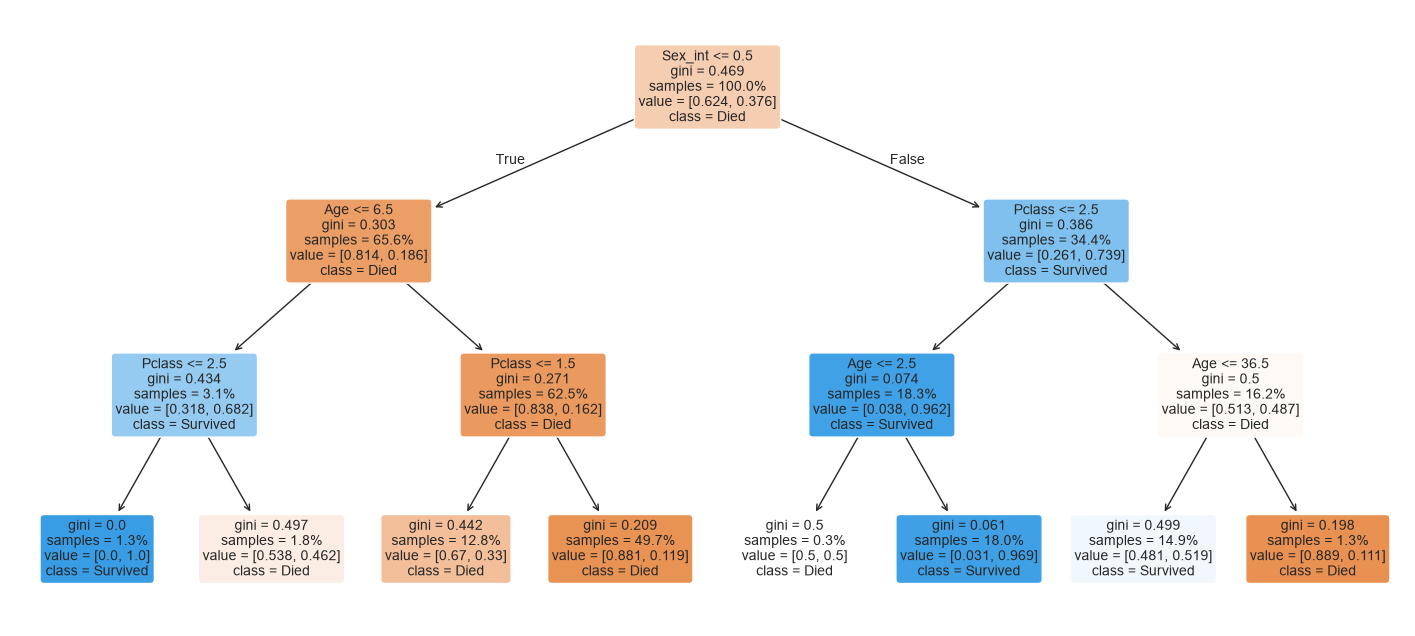

In [5]:
features_3 = ["Sex_int", "Age", "Pclass"]

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(train[features_3], y_train)

plt.figure(figsize=(18, 8))
plot_tree(tree, feature_names=features_3, class_names=["Died", "Survived"],
          filled=True, rounded=True, proportion=True, fontsize=10)
plt.show()

Each box shows the question (e.g. `Sex_int <= 0.5`, i.e. male), the share of training passengers reaching that node (`samples`), the survival proportions (`value`), and the majority class. Colour intensity shows how "pure" the node is.

### Exercise

1. Follow the tree for a **30-year-old woman in 3rd class**. Which leaf does she end up in, and what does the tree predict?
2. Use `tree.predict()` to check your answer. (Hint: build a one-row DataFrame with columns `Sex_int`, `Age`, `Pclass`.)
3. What is the *first* question the tree asks, and why do you think it chose that one?

In [6]:
# your code here

## 1.4 The random forest

A single tree is unstable: change a few passengers and you may get a different tree. A **random forest** grows many trees (here 100), each on a bootstrap sample of the training data and a random subset of features at each split, then lets them vote. Let's follow the lecture and add features step by step.

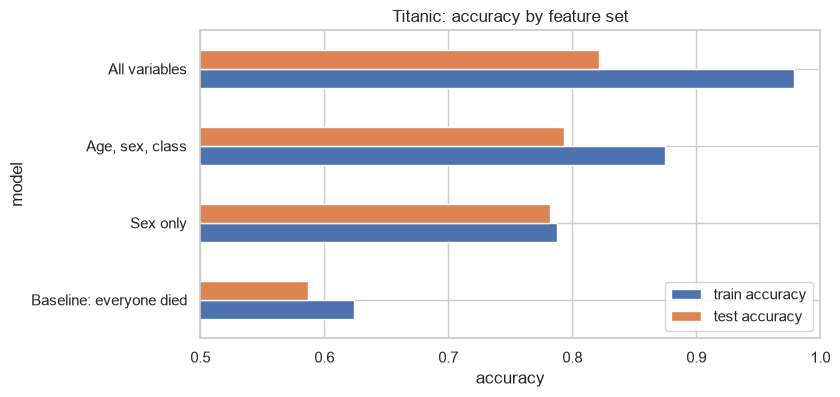

,train accuracy,test accuracy
model,,
Baseline: everyone died,0.624,0.587
Sex only,0.788,0.782
"Age, sex, class",0.875,0.793
All variables,0.979,0.821


In [7]:
feature_sets = {
    "Sex only": ["Sex_int"],
    "Age, sex, class": ["Age", "Sex_int", "Pclass"],
    "All variables": ["Age", "Pclass", "Sex_int", "Embarked_int", "SibSp", "Parch", "Fare"],
}

results = []
models = {}
for name, feats in feature_sets.items():
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(train[feats], y_train)
    models[name] = rf
    results.append({"model": name,
                    "train accuracy": accuracy_score(y_train, rf.predict(train[feats])),
                    "test accuracy": accuracy_score(y_test, rf.predict(test[feats]))})

baseline = DummyClassifier(strategy="most_frequent").fit(train[["Sex_int"]], y_train)
results.insert(0, {"model": "Baseline: everyone died",
                   "train accuracy": accuracy_score(y_train, baseline.predict(train[["Sex_int"]])),
                   "test accuracy": accuracy_score(y_test, baseline.predict(test[["Sex_int"]]))})

results = pd.DataFrame(results).set_index("model")
results.plot.barh(figsize=(8, 4), xlim=(0.5, 1))
plt.xlabel("accuracy")
plt.title("Titanic: accuracy by feature set")
plt.show()
results.round(3)

Two things to notice:

- Knowing only a passenger's sex already gets us most of the way; extra features add a few points on the test set.
- With all variables, **training** accuracy is ~98% but **test** accuracy is ~82%. The gap is the model memorising individual training passengers (think of `Fare` and `Age`, which are nearly unique for each person). We'll come back to this in Part 2.4.

# Part 2: How accurate is accuracy?

## 2.1 The confusion matrix

Accuracy lumps all mistakes together. The **confusion matrix** separates them. With "survived" as the **positive** class:

- **True positive (TP)**: predicted survived, did survive
- **False positive (FP)**: predicted survived, actually died (the boy crying "wolf!" with no wolf)
- **False negative (FN)**: predicted died, actually survived (a wolf nobody warned about)
- **True negative (TN)**: predicted died, did die

From these: **precision** = TP / (TP + FP), "when the model says *survived*, how often is it right?"; **recall** = TP / (TP + FN), "of those who survived, how many did the model find?"; **F1** is the harmonic mean of the two.

TP=57 FP=15 FN=17 TN=90
Accuracy 0.82 | Precision 0.79 | Recall 0.77 | F1 0.78


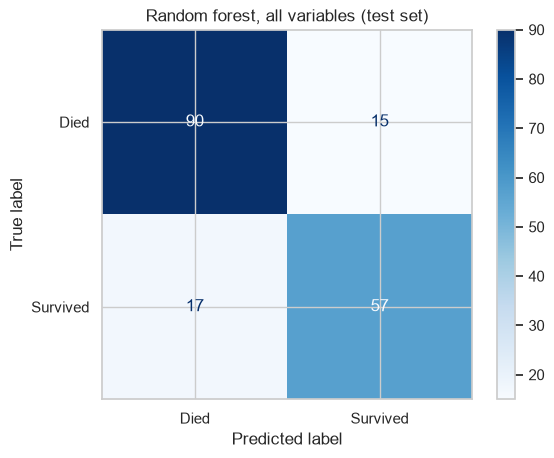

In [8]:
all_vars = feature_sets["All variables"]
rf_all = models["All variables"]
y_pred = rf_all.predict(test[all_vars])

tp = ((y_test == 1) & (y_pred == 1)).sum()
fp = ((y_test == 0) & (y_pred == 1)).sum()
fn = ((y_test == 1) & (y_pred == 0)).sum()
tn = ((y_test == 0) & (y_pred == 0)).sum()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
print(f"TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"Accuracy {accuracy:.2f} | Precision {precision:.2f} | Recall {recall:.2f} | F1 {f1:.2f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Died", "Survived"], cmap="Blues")
plt.title("Random forest, all variables (test set)")
plt.show()

These match the lecture's "All variables" slide to within a point (small differences come from how missing ages are filled). scikit-learn has these metrics built in, so from now on we'll use `accuracy_score`, `precision_score`, `recall_score` and `f1_score` rather than counting by hand.

## 2.2 The tumour example

The lecture's tumour classifier saw 100 tumours: TP = 1, FP = 1, FN = 8, TN = 90. Its accuracy is 91%, which sounds great. Let's rebuild it and compare it with a "model" that always says *benign*.

In [9]:
# 1 = malignant (positive), 0 = benign
observed = np.array([1]*1 + [0]*1 + [1]*8 + [0]*90)
model_pred = np.array([1]*1 + [1]*1 + [0]*8 + [0]*90)
always_benign = np.zeros(100, dtype=int)

for name, pred in [("tumour model", model_pred), ("always benign", always_benign)]:
    print(f"{name:14s} accuracy {accuracy_score(observed, pred):.2f}  "
          f"precision {precision_score(observed, pred, zero_division=0):.2f}  "
          f"recall {recall_score(observed, pred):.2f}  "
          f"F1 {f1_score(observed, pred):.2f}")

tumour model   accuracy 0.91  precision 0.50  recall 0.11  F1 0.18
always benign  accuracy 0.91  precision 0.00  recall 0.00  F1 0.00


Same accuracy, but the model misses 8 of 9 cancers (recall 0.11). When one class is rare, **accuracy mostly measures how common the majority class is** (the base rate), not how good the model is.

## 2.3 An imbalanced problem in real data

The Titanic overall is fairly balanced (38% survived). But look at **men travelling 3rd class**: only about 1 in 7 survived. Let's train a forest just for them and compare it with the "everyone died" baseline, and with a forest told to pay extra attention to the rare class (`class_weight="balanced"`).

Survival rate among 3rd-class men (train): 14.1%; test set n = 64


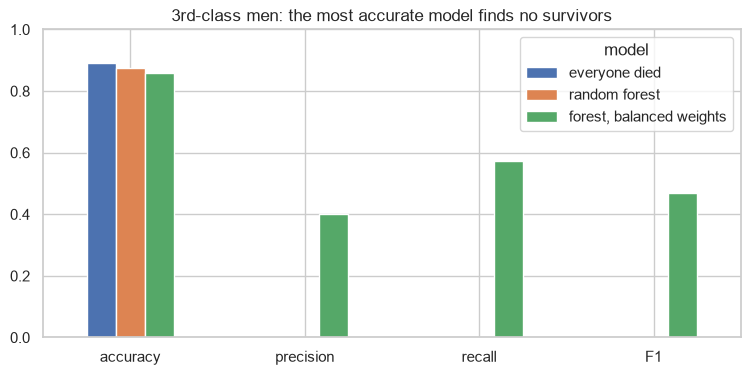

,accuracy,precision,recall,F1
model,,,,
everyone died,0.89,0.0,0.00,0.00
random forest,0.88,0.0,0.00,0.00
"forest, balanced weights",0.86,0.4,0.57,0.47


In [10]:
m3_train = train[(train["Sex"] == "male") & (train["Pclass"] == 3)]
m3_test = test[(test["Sex"] == "male") & (test["Pclass"] == 3)]
feats_m3 = ["Age", "SibSp", "Parch", "Fare", "Embarked_int"]
print(f"Survival rate among 3rd-class men (train): {m3_train['Survived'].mean():.1%}; test set n = {len(m3_test)}")

rf_m3 = RandomForestClassifier(n_estimators=100, random_state=42).fit(m3_train[feats_m3], m3_train["Survived"])
dummy_m3 = DummyClassifier(strategy="most_frequent").fit(m3_train[feats_m3], m3_train["Survived"])

# class_weight="balanced" tells the forest to treat each (rare) survivor as if it counted more
rf_m3_bal = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced").fit(
    m3_train[feats_m3], m3_train["Survived"])

rows = []
for name, mdl in [("everyone died", dummy_m3), ("random forest", rf_m3), ("forest, balanced weights", rf_m3_bal)]:
    p = mdl.predict(m3_test[feats_m3])
    rows.append({"model": name,
                 "accuracy": accuracy_score(m3_test["Survived"], p),
                 "precision": precision_score(m3_test["Survived"], p, zero_division=0),
                 "recall": recall_score(m3_test["Survived"], p),
                 "F1": f1_score(m3_test["Survived"], p, zero_division=0)})
m3_results = pd.DataFrame(rows).set_index("model")
m3_results.T.plot.bar(figsize=(9, 4), rot=0, ylim=(0, 1))
plt.title("3rd-class men: the most accurate model finds no survivors")
plt.show()
m3_results.round(2)

### Exercise

1. Which model has the highest **accuracy**? Which would you rather use to find survivors, and why? What did the balanced forest give up to get its higher recall?
2. The test set contains 64 of these men. How much would you trust the precision and recall numbers? (Count the actual survivors in `m3_test`: how many people does each recall value correspond to?)
3. Think of a real application where a **false negative** is much worse than a false positive, and one where the reverse is true. Which metric would you prioritise in each?

In [11]:
# your code here

## 2.4 Overfitting: train vs test as the tree grows

A deeper tree can ask more questions, so it can fit the training data ever more closely. Eventually each leaf holds a single passenger, and the tree has memorised the training set. Let's plot training and test accuracy for trees of increasing depth.

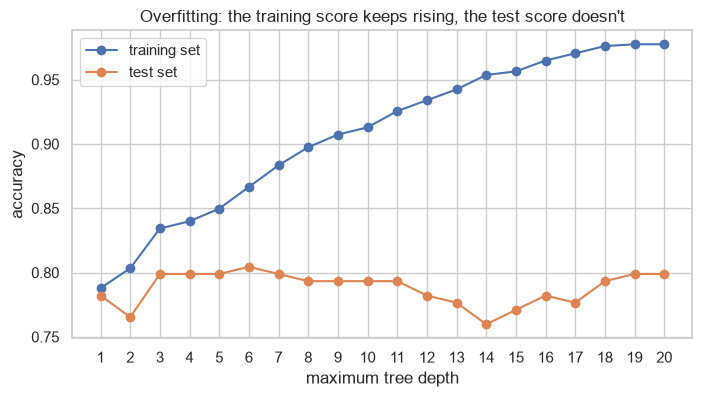

In [12]:
depths = range(1, 21)
train_acc, test_acc = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(train[all_vars], y_train)
    train_acc.append(accuracy_score(y_train, t.predict(train[all_vars])))
    test_acc.append(accuracy_score(y_test, t.predict(test[all_vars])))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_acc, marker="o", label="training set")
plt.plot(depths, test_acc, marker="o", label="test set")
plt.xlabel("maximum tree depth")
plt.ylabel("accuracy")
plt.title("Overfitting: the training score keeps rising, the test score doesn't")
plt.xticks(list(depths))
plt.legend()
plt.show()

Training accuracy keeps climbing (it stops just short of 100% only because a few passengers have identical features but different fates); test accuracy stops improving after a depth of about 3 and then wobbles around or below that level. The widening gap is **overfitting**: the tree is learning noise specific to the training passengers.

## 2.5 Cross-validation

We have been judging models on one particular test set of 179 passengers. A different random split would give different numbers. **k-fold cross-validation** splits the training data into k folds, holds each one out in turn, and averages the k scores. That tells us both the typical score and how much it varies.

Crucially, we use cross-validation *within the training set* to choose settings like tree depth, and keep the test set for one final check. If we picked the depth that looked best on the test set, the test set would no longer be "unseen".

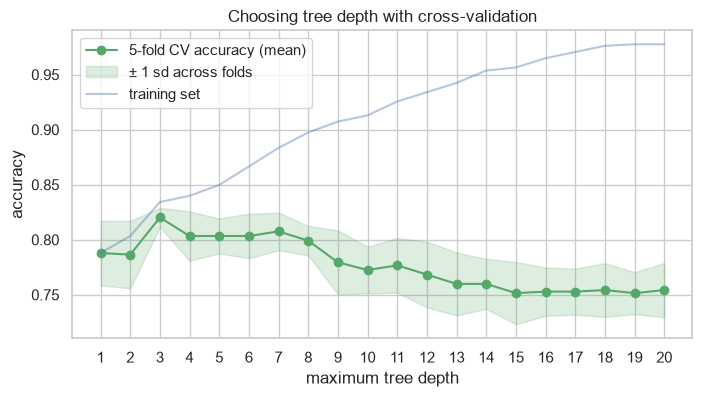

Best depth by CV: 3 (CV accuracy 0.820 ± 0.009)


In [13]:
cv_mean, cv_sd = [], []
for d in depths:
    scores = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                             train[all_vars], y_train, cv=5, scoring="accuracy")
    cv_mean.append(scores.mean())
    cv_sd.append(scores.std())
cv_mean, cv_sd = np.array(cv_mean), np.array(cv_sd)

plt.figure(figsize=(8, 4))
plt.plot(depths, cv_mean, marker="o", color="C2", label="5-fold CV accuracy (mean)")
plt.fill_between(depths, cv_mean - cv_sd, cv_mean + cv_sd, color="C2", alpha=0.2, label="± 1 sd across folds")
plt.plot(depths, train_acc, color="C0", alpha=0.4, label="training set")
plt.xlabel("maximum tree depth")
plt.ylabel("accuracy")
plt.xticks(list(depths))
plt.legend()
plt.title("Choosing tree depth with cross-validation")
plt.show()

best_depth = int(np.array(depths)[cv_mean.argmax()])
print(f"Best depth by CV: {best_depth} (CV accuracy {cv_mean.max():.3f} ± {cv_sd[cv_mean.argmax()]:.3f})")

### Exercise

1. Fit a `DecisionTreeClassifier` with `max_depth=best_depth` on the full training set and report its accuracy on the test set, **once**.
2. Look at the width of the shaded band. Is the difference in CV accuracy between the best depth and, say, depth 5 bigger than the fold-to-fold variation? What does that tell you about claims like "model A beats model B by 1 percentage point"?
3. Run `cross_val_score` on the random forest with all variables (`cv=5`). Is it better than the best single tree?

In [14]:
# your code here

## 2.6 Feature importance, and its caveats

Random forests report how much each feature reduced impurity across all splits (`feature_importances_`). An alternative, **permutation importance**, shuffles one feature at a time in the *test* set and measures how much accuracy drops.

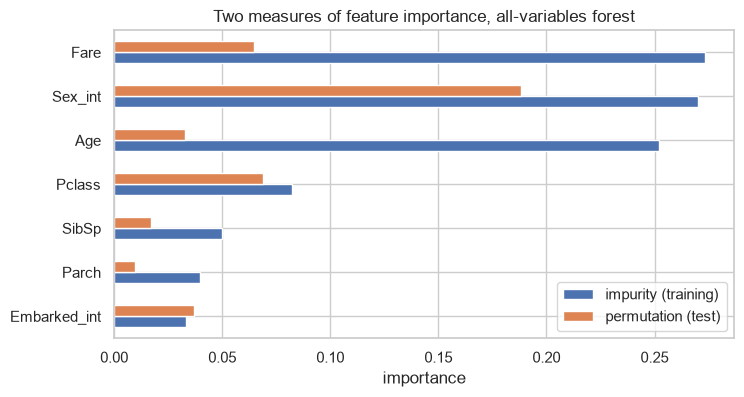

,impurity (training),permutation (test)
Embarked_int,0.033,0.037
Parch,0.040,0.010
SibSp,0.050,0.017
Pclass,0.082,0.069
Age,0.252,0.033
Sex_int,0.270,0.188
Fare,0.273,0.065


In [15]:
imp = pd.DataFrame({"impurity (training)": rf_all.feature_importances_}, index=all_vars)
perm = permutation_importance(rf_all, test[all_vars], y_test, n_repeats=20, random_state=42)
imp["permutation (test)"] = perm.importances_mean
imp = imp.sort_values("impurity (training)")

imp.plot.barh(figsize=(8, 4))
plt.title("Two measures of feature importance, all-variables forest")
plt.xlabel("importance")
plt.show()
imp.round(3)

The two measures disagree, and neither is "the effect" of a feature. Caveats to keep in mind:

- **Impurity importance favours continuous, many-valued features** such as `Fare` and `Age`: they offer many possible split points, so they get used a lot, including for memorising noise.
- **Correlated features share credit.** `Fare` and `Pclass` carry similar information, so the forest can use either; each looks less important than the information they jointly hold.
- **Importance is predictive, not causal.** A feature is "important" if it helps prediction, not because changing it would change the outcome.

### Exercise

Which feature ranks much higher on impurity importance than on permutation importance? Using the caveats above, explain why in one or two sentences.

In [16]:
# your code here

## 2.7 Spot the problem: a suspiciously good model

A classmate has found an extended version of the passenger list (1,309 passengers, [Vanderbilt Biostatistics](https://hbiostat.org/data/repo/titanic3.csv)) with two extra columns: `boat` (lifeboat number, if any) and `body` (body identification number, if the body was recovered). They report a model that is **97% accurate**. Here is their analysis:

Test accuracy: 0.973


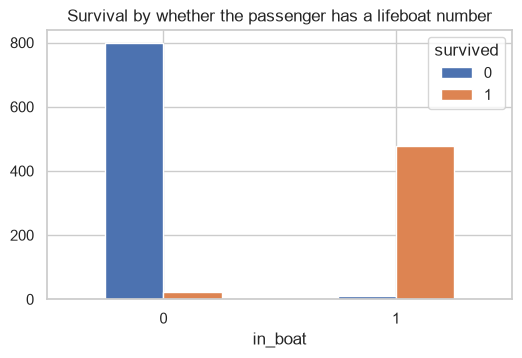

In [17]:
t3 = pd.read_csv("https://storage.googleapis.com/qm2/2627/w09/titanic3.csv")

t3["sex_int"] = (t3["sex"] == "female").astype(int)
t3["age"] = t3["age"].fillna(t3["age"].median())
t3["fare"] = t3["fare"].fillna(t3["fare"].median())
t3["in_boat"] = t3["boat"].notna().astype(int)
t3["body_found"] = t3["body"].notna().astype(int)

colleague_feats = ["pclass", "sex_int", "age", "fare", "in_boat", "body_found"]
X_tr, X_te, y_tr, y_te = train_test_split(t3[colleague_feats], t3["survived"], test_size=0.2, random_state=42)
rf_leaky = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_tr)
print(f"Test accuracy: {accuracy_score(y_te, rf_leaky.predict(X_te)):.3f}")

pd.crosstab(t3["in_boat"], t3["survived"]).plot.bar(rot=0, figsize=(6, 3.5))
plt.title("Survival by whether the passenger has a lifeboat number")
plt.show()

### Exercise

1. What is wrong with this model? Use the lecture's definition of **leakage**: would the model have this information at the moment it needs to make a prediction (e.g. at boarding)?
2. `body_found` is leaky too, but in a different direction. Explain.
3. There is a second, subtler problem in the code: look at how missing `age` and `fare` are filled. Why does that break the "test data is unseen" rule, and how would you fix it? (Compare with Part 1.2.)
4. Refit the model **without** the leaky features (and with the imputation fixed). How accurate is it now?

In [18]:
# your code here

# Part 3: What gear is that vessel using?

Different fishing gears have very different impacts: bottom trawlers scrape the seabed, drifting longlines catch sharks and turtles as bycatch, purse seiners encircle whole schools of tuna. Fisheries rules are often gear-specific, so monitoring needs to know **which vessel uses which gear**. Many vessels, though, are not in any public registry, or their registry entry is wrong or out of date.

[Global Fishing Watch](https://globalfishingwatch.org) (GFW) tracks fishing vessels through their AIS transponders and publishes, for each vessel and year, its size, engine power, hours active and hours fishing. For vessels that *are* in registries, we know the registered gear type. Could a model learn to predict gear from size and behaviour, and fill the gaps for unregistered vessels?

**Data**: an extract of GFW's public `fishing_vessels_v3` table: vessel-years 2022 to 2024 where the vessel has a single registered gear type and registered length, tonnage and engine power. *Source: Global Fishing Watch, [CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/).*

| column | meaning |
|---|---|
| `mmsi` | the vessel's AIS identifier |
| `year` | year |
| `flag` | flag state (ISO3) |
| `gear_registry` | gear type from vessel registries (**our label**) |
| `gear_inferred` | gear type predicted by GFW's neural network from AIS movement; `gear_inferred_score` is its confidence |
| `gear_gfw` | GFW's final gear type "after considering all available information" (registry + model) |
| `length_m`, `tonnage_gt`, `engine_power_kw` | registered length (m), gross tonnage, engine power (kW) |
| `active_hours`, `fishing_hours` | hours moving, and hours detected as fishing, that year |

In [19]:
vessels = pd.read_csv("https://storage.googleapis.com/qm2/2627/w09/fishing_vessels_gear.csv", dtype={"mmsi": str})
print(vessels.shape)
vessels.head()

(25019, 12)


,mmsi,year,flag,gear_registry,gear_inferred,gear_inferred_score,gear_gfw,length_m,tonnage_gt,engine_power_kw,active_hours,fishing_hours
0,100902469,2022,CIV,drifting_longlines,drifting_longlines,1.000,drifting_longlines,47.2,380.0,745.7,4779.3,3408.6
1,123450020,2022,MEX,purse_seines,purse_seines,0.879,purse_seines,71.5,1443.5,2685.6,762.7,303.3
2,124013460,2022,ESP,trawlers,trawlers,1.000,trawlers,23.0,98.8,367.7,4297.8,941.8
3,124044690,2022,ESP,set_gillnets,set_longlines,0.852,fixed_gear,27.0,197.4,399.4,506.5,290.9
4,124048850,2022,ESP,trawlers,trawlers,1.000,trawlers,25.0,85.4,272.8,641.6,98.0


## 3.1 Explore

As always, look first. How common is each gear, and do gears differ in size?

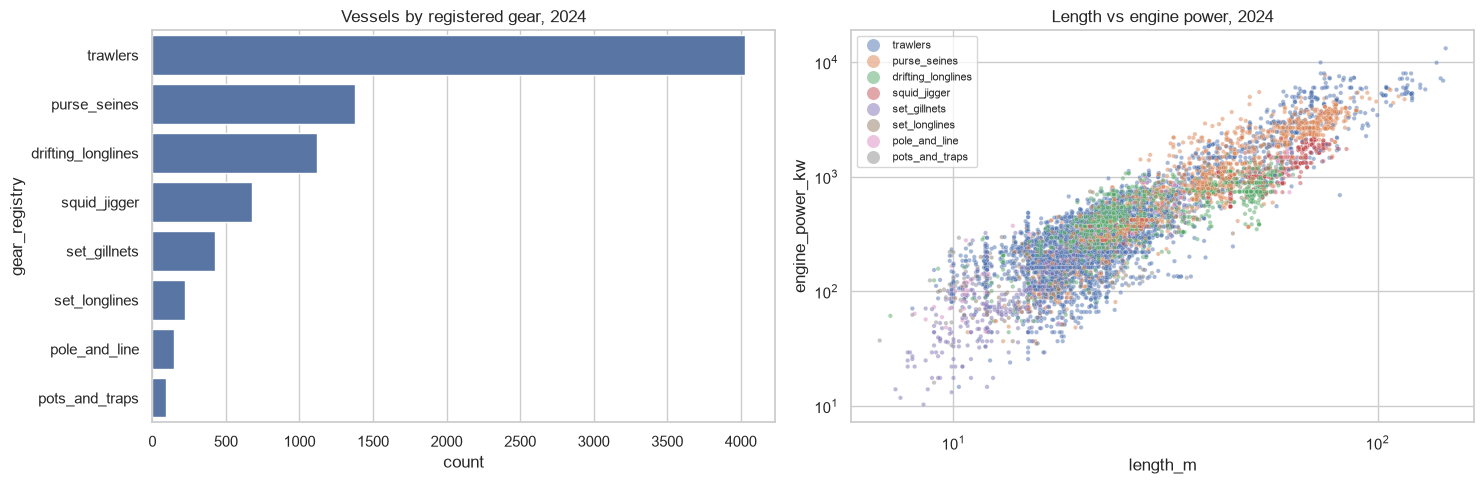

In [20]:
v24 = vessels[vessels["year"] == 2024].copy()
order = v24["gear_registry"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=v24, y="gear_registry", order=order, ax=axes[0])
axes[0].set_title("Vessels by registered gear, 2024")
sns.scatterplot(data=v24, x="length_m", y="engine_power_kw", hue="gear_registry", hue_order=order,
                s=10, alpha=0.5, ax=axes[1])
axes[1].set(xscale="log", yscale="log", title="Length vs engine power, 2024")
axes[1].legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

Trawlers make up about half of the vessels: an "always trawler" model would be ~50% accurate, and it would never find a single pots-and-traps vessel. Some gears (squid jiggers, tuna purse seiners) form fairly distinct clusters by size; others overlap heavily.

## 3.2 Where do the labels come from? Label quality

In the lecture, a damage-detection model was only as good as the damage labels it learned from, and labels drawn in one city didn't transfer to another. The same question applies here. Our "true" label is the **registry** gear. GFW also produces an **inferred** gear from AIS movement patterns. How often do they agree?

Registry and inferred gear agree for 87.1% of 2024 vessels


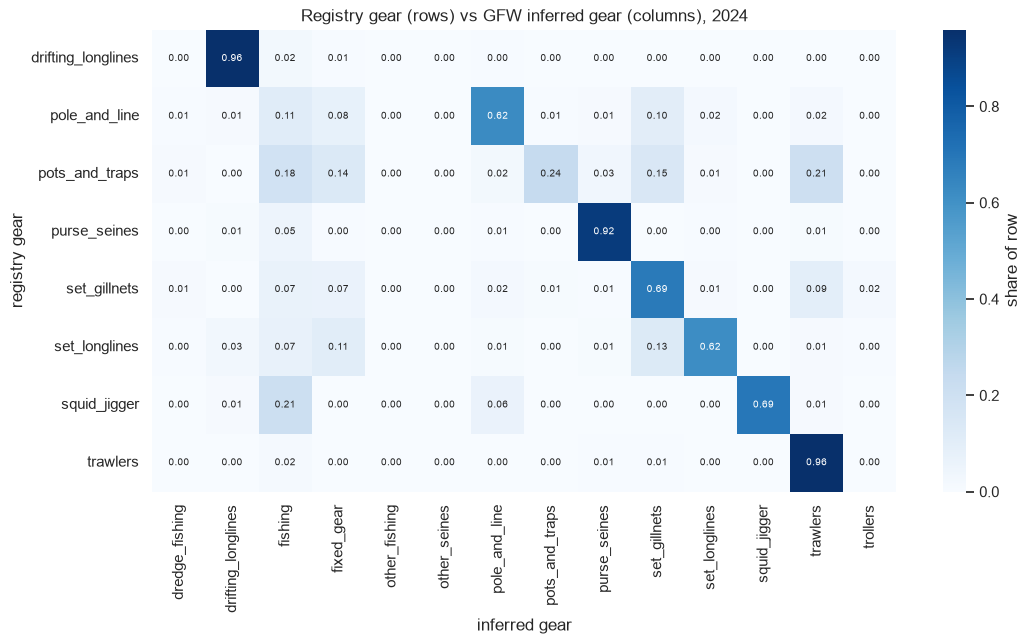

In [21]:
agree = (v24["gear_registry"] == v24["gear_inferred"])
print(f"Registry and inferred gear agree for {agree.mean():.1%} of 2024 vessels")

ct = pd.crosstab(v24["gear_registry"], v24["gear_inferred"], normalize="index")
plt.figure(figsize=(12, 6))
sns.heatmap(ct, cmap="Blues", annot=True, fmt=".2f", annot_kws={"size": 7}, cbar_kws={"label": "share of row"})
plt.title("Registry gear (rows) vs GFW inferred gear (columns), 2024")
plt.xlabel("inferred gear"); plt.ylabel("registry gear")
plt.show()

### Exercise

1. For which registry gears does the inferred label disagree most often? Where do those vessels end up instead?
2. When they disagree, who is right? Give one reason the **registry** could be wrong (e.g. vessels switch gear seasonally; registries are updated slowly; one vessel may be licensed for several gears) and one reason the **inferred** label could be wrong.
3. GFW's own neural network was trained on registry labels. If registries systematically mislabel a gear in one region, what will the model learn? Relate this to the Aleppo damage-labels example from the lecture.

In [22]:
# your code here

## 3.3 Main exercise: predict gear type from size and behaviour

### Exercise

Using the **2024** vessels (`v24`):

1. Define the features `["length_m", "tonnage_gt", "engine_power_kw", "active_hours", "fishing_hours"]` and the label `gear_registry`.
2. Split into train and test sets (25% test) with `random_state=42`. Use `stratify=` so that rare gears appear in both sets in proportion (look it up in the `train_test_split` docs).
3. Fit a majority-class `DummyClassifier` baseline and a `RandomForestClassifier(n_estimators=200, random_state=42)`. Report the test accuracy of both.
4. Plot the confusion matrix (`ConfusionMatrixDisplay.from_predictions(..., normalize="true", xticks_rotation=90)`), and print `classification_report`. Which gears does the model find well (high recall)? Which does it almost never find?
5. Compare the plain average of per-class F1 (`f1_score(..., average="macro")`) with accuracy. Why are they so different?
6. Plot feature importances. Does activity (`fishing_hours`) matter as much as size?

In [23]:
features = ["length_m", "tonnage_gt", "engine_power_kw", "active_hours", "fishing_hours"]

# your code here

### Exercise: interpretation

GFW wants to use a model like yours to assign gear types to **unregistered** vessels. Write three or four sentences for a policy audience: how far should they trust its predictions, for which gears, and what could go wrong? Think about whether unregistered vessels resemble the registered ones the model was trained on.

## 3.4 Spot the problem: 96% accuracy

A colleague wants more data, so they use **all three years** (2022 to 2024) and only the three registry measurements (length, tonnage, engine power). Their accuracy jumps from about 76% (the 2024-only model in 3.3) to 96%:

Test accuracy, all years, random split: 0.964


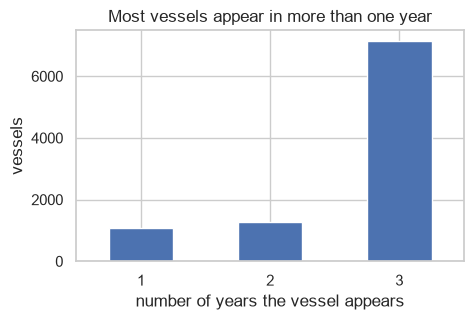

In [24]:
static = ["length_m", "tonnage_gt", "engine_power_kw"]
X_tr, X_te, y_tr, y_te = train_test_split(vessels[static], vessels["gear_registry"], test_size=0.25, random_state=42)
rf_static = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
print(f"Test accuracy, all years, random split: {accuracy_score(y_te, rf_static.predict(X_te)):.3f}")

per_vessel = vessels.groupby("mmsi").size()
per_vessel.value_counts().sort_index().plot.bar(rot=0, figsize=(5, 3))
plt.xlabel("number of years the vessel appears"); plt.ylabel("vessels")
plt.title("Most vessels appear in more than one year")
plt.show()

### Exercise

1. What has gone wrong? (Hint: pick one `mmsi` that appears three times and look at its rows. Would the registered length of the same boat change between years?)
2. Which item on the lecture's leakage slide is this?
3. Fix it: split so that **all rows for a given vessel land on the same side** of the split. `GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)` with `groups=vessels["mmsi"]` does this; `next(gss.split(X, y, groups))` returns train and test row positions. What is the honest accuracy?
4. A second colleague adds `gear_gfw` as a feature and gets near-perfect accuracy. Read its description in the table above. Why is this also leakage?

In [25]:
# your code here

## Optional extensions

### Optional: does flag state help, and is it fair to use it?

Add the vessel's `flag` as a feature (e.g. one-hot encode the 15 most common flags with `pd.get_dummies`, grouping the rest as "other"). Does accuracy improve? The model may now learn "Chinese-flagged, 60 m → squid jigger". Is that a genuine signal, or a shortcut that would fail for a new fleet? How is this like the Aleppo model failing in other cities?

### Optional: tune the forest honestly

Use `cross_val_score` on the 2024 **training** set to choose `max_depth` for the gear model (try `None, 5, 10, 20`). Evaluate the chosen model on the test set once.

### Optional: feature engineering on the Titanic

The `Name` column contains titles (Mr, Mrs, Miss, Master, Dr, Rev...). Extract the title with `df["Name"].str.extract(r",\s*([^\.]+)\.")`, turn the common ones into features, and see whether they improve the cross-validated accuracy of the all-variables forest. Remember to create the feature in a way that doesn't use the test set.

In [26]:
# your code here

## Summary

- **Split first**, and keep the test set unseen, including for preprocessing steps like imputation.
- A **baseline** (predict the most common class) is the number to beat.
- **Accuracy** hides the kind of mistakes a model makes. With imbalanced classes, look at the **confusion matrix**, **precision** and **recall** per class.
- Training accuracy always rises with model complexity; test (or cross-validated) accuracy tells you when you are **overfitting**.
- Before believing an impressive score, ask: *could the model have seen the answer?* Features recorded after the outcome, and the same unit in both train and test, are the classic forms of **leakage**.
- A model is only as good as its **labels**. Ask where they came from, and whether the cases you want to predict look like the ones you trained on.

Next week: **unsupervised learning**, where there are no labels at all.